In [ ]:
pip install numpy scipy torch torchaudio librosa pydub matplotlib transformers huggingface-hub

# Adversarial Attack on Wav2Vec2

PGD attack on the CTC loss, plus psychoacoustic masking and energy-based filtering to keep the perturbation within an L-inf budget and away from perceptually salient frequencies. See section 5 for what actually happens when the loss weighting is tuned, versus what a recruiter would assume happens.

## 1. Setup: model, helper functions, and the attack

Loads the Wav2Vec2 processor/model and defines:
- `convert_audio` - normalize any input file to 16kHz mono PCM16.
- `bark_scale` / `apply_psychoacoustic_masking` - shape perturbation energy away from frequencies the ear is most sensitive to.
- `apply_energy_filter` - damp the perturbation further in quiet (low-energy) regions.
- `run_pgd_attack` - the PGD attack on the CTC loss, parameterized by `epsilon`/`alpha`/`num_iter` so it isn't copy-pasted per configuration.

**Fix vs. the previous version of this notebook:** psychoacoustic masking and energy filtering are applied *inside* the PGD loop, and the perturbation is re-projected onto `[-epsilon, epsilon]` *after* that post-processing. Without that re-projection, masking/filtering silently pushed the real perturbation to 5-6x the stated epsilon budget (verified: `epsilon=0.03` was producing a max perturbation of `0.175`).

In [ ]:
import json
import os

import librosa
import numpy as np
import scipy.io.wavfile as wav
import torch
import torchaudio
from jiwer import wer

from attack_lib import project_to_epsilon_ball
from pydub import AudioSegment
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor


def convert_audio(input_path):
    """Convert any input audio file to 16kHz mono PCM16, which is what Wav2Vec2 expects."""
    base, ext = os.path.splitext(input_path)
    output_path = f"{base}_converted.wav"
    audio = AudioSegment.from_file(input_path)
    audio = audio.set_frame_rate(16000).set_channels(1).set_sample_width(2)
    audio.export(output_path, format="wav")
    return output_path


def bark_scale(freq):
    """Convert a frequency in Hz to the Bark psychoacoustic scale."""
    return 13 * np.arctan(0.00076 * freq) + 3.5 * np.arctan((freq / 7500.0) ** 2)


def apply_psychoacoustic_masking(waveform, sr=16000):
    """Shape perturbation energy toward frequency bands the ear is less sensitive to."""
    waveform_np = waveform.detach().cpu().numpy()
    stft = librosa.stft(waveform_np, n_fft=512, hop_length=128)
    magnitude, phase = np.abs(stft), np.angle(stft)

    freqs = librosa.fft_frequencies(sr=sr, n_fft=512)
    bark_bins = bark_scale(freqs)
    mask = np.exp(-bark_bins / np.max(bark_bins))
    masked_magnitude = magnitude * mask[:, np.newaxis]

    modified_stft = masked_magnitude * np.exp(1j * phase)
    modified_waveform = librosa.istft(modified_stft, hop_length=128)

    out = torch.tensor(modified_waveform, dtype=torch.float32)
    # istft can shift the sample count by a few frames; keep it aligned with the input.
    if out.shape[0] < waveform.shape[0]:
        out = torch.nn.functional.pad(out, (0, waveform.shape[0] - out.shape[0]))
    elif out.shape[0] > waveform.shape[0]:
        out = out[: waveform.shape[0]]
    return out


def apply_energy_filter(adv_audio, energy_factor=0.8):
    """Damp the perturbation more in low-energy (quiet) regions, where it would stand out most."""
    window = torch.hann_window(512)
    energy = torch.abs(torch.stft(adv_audio, n_fft=512, window=window, return_complex=True)).mean(dim=1)
    high_energy_mask = (energy > torch.mean(energy)).float()
    high_energy_mask = torch.nn.functional.interpolate(
        high_energy_mask.unsqueeze(0).unsqueeze(0),
        size=adv_audio.shape[0],
        mode="linear",
        align_corners=False,
    ).squeeze()
    adaptive_mask = energy_factor + (1 - energy_factor) * high_energy_mask
    return adv_audio * adaptive_mask


def transcribe(processor, model, waveform_1d):
    inputs = processor(waveform_1d, sampling_rate=16000, return_tensors="pt", padding=True)
    input_values = inputs.input_values
    if input_values.dim() == 3:
        input_values = input_values.squeeze(0)
    with torch.no_grad():
        logits = model(input_values).logits
    predicted_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(predicted_ids)[0], logits

In [ ]:
def run_pgd_attack(
    processor,
    model,
    waveform,
    epsilon,
    alpha,
    num_iter,
    use_psychoacoustic_masking=True,
    use_energy_filter=True,
    energy_factor=0.8,
    entropy_weight=0.2,
):
    """PGD attack on the CTC loss, re-projected onto the L-inf epsilon ball every step."""
    audio_tensor = waveform.clone().detach()
    text_original, logits = transcribe(processor, model, audio_tensor)

    target = processor.tokenizer(text_original, return_tensors="pt").input_ids.squeeze(0)
    input_lengths = torch.tensor([logits.shape[1]], dtype=torch.long)
    target_lengths = torch.tensor([min(target.shape[0], logits.shape[1])], dtype=torch.long)
    ctc_loss = torch.nn.CTCLoss(blank=processor.tokenizer.pad_token_id)

    adv_audio = audio_tensor.clone().detach().requires_grad_(True)
    losses = []

    for _ in range(num_iter):
        adv_audio = adv_audio.clone().detach().requires_grad_(True)

        logits = model(adv_audio.unsqueeze(0)).logits
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        entropy_loss = -torch.sum(log_probs * torch.exp(log_probs))
        alignment_loss = ctc_loss(log_probs.transpose(0, 1), target, input_lengths, target_lengths)
        loss = alignment_loss + entropy_weight * entropy_loss
        loss.backward()
        losses.append(loss.item())

        with torch.no_grad():
            grad_abs_max = torch.max(torch.abs(adv_audio.grad))
            adaptive_alpha = alpha * torch.abs(adv_audio.grad) / (grad_abs_max + 1e-12)
            perturbation = adaptive_alpha * torch.sign(adv_audio.grad)
            adv_audio = adv_audio + perturbation

            if use_psychoacoustic_masking:
                adv_audio = apply_psychoacoustic_masking(adv_audio)
            if use_energy_filter:
                adv_audio = apply_energy_filter(adv_audio, energy_factor=energy_factor)

            adv_audio = project_to_epsilon_ball(adv_audio, audio_tensor, epsilon)

    adv_audio = adv_audio.detach()
    text_adversarial, _ = transcribe(processor, model, adv_audio)

    diff = (adv_audio - audio_tensor).numpy()
    signal_power = float(np.mean(audio_tensor.numpy() ** 2))
    noise_power = float(np.mean(diff ** 2)) + 1e-12
    snr_db = 10 * np.log10(signal_power / noise_power)

    metrics = {
        "epsilon": epsilon,
        "alpha": alpha,
        "num_iter": num_iter,
        "text_original": text_original,
        "text_adversarial": text_adversarial,
        "word_error_rate": wer(text_original, text_adversarial),
        "linf_perturbation": float(np.max(np.abs(diff))),
        "l2_perturbation": float(np.linalg.norm(diff)),
        "snr_db": snr_db,
        "final_loss": losses[-1],
    }
    return adv_audio, metrics

## 2. Load the ASR model

In [ ]:
MODEL_NAME = "facebook/wav2vec2-large-960h"
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME, ignore_mismatched_sizes=True)
model.eval()

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 3. Run the attack across samples and perturbation budgets

Two short, license-free sample clips are committed under `samples/` (synthetic text-to-speech audio, not a copyrighted recording or anyone's voice) and run through two `epsilon` budgets each: a `mild` setting that should barely register on the transcription, and a `strong` setting meant to visibly degrade it while staying within a small L-inf bound.

In [ ]:
SAMPLES_DIR = "samples"
SAMPLE_STEMS = ["sample1_pangram", "sample2_tech"]
CONFIGS = [
    {"name": "mild", "epsilon": 0.015, "alpha": 0.005, "num_iter": 10},
    {"name": "strong", "epsilon": 0.04, "alpha": 0.013, "num_iter": 10},
]

results = []
for stem in SAMPLE_STEMS:
    raw_path = f"{SAMPLES_DIR}/{stem}_raw.wav"
    converted_path = convert_audio(raw_path)
    waveform, sr = torchaudio.load(converted_path)
    assert sr == 16000
    waveform = waveform.mean(dim=0)
    waveform = waveform / waveform.abs().max()

    for cfg in CONFIGS:
        print(f"running {stem} / {cfg['name']} ...")
        adv_audio, metrics = run_pgd_attack(
            processor, model, waveform,
            epsilon=cfg["epsilon"], alpha=cfg["alpha"], num_iter=cfg["num_iter"],
        )
        metrics["sample"] = stem
        metrics["config"] = cfg["name"]
        results.append(metrics)

        out_wav = f"{SAMPLES_DIR}/{stem}_{cfg['name']}_adversarial.wav"
        wav.write(out_wav, 16000, (adv_audio.numpy() * 32768).astype(np.int16))

        print(f"[{stem} / {cfg['name']}]")
        print(f"  original:    {metrics['text_original']}")
        print(f"  adversarial: {metrics['text_adversarial']}")
        print(f"  WER={metrics['word_error_rate']:.3f}  Linf={metrics['linf_perturbation']:.4f}"
              f"  L2={metrics['l2_perturbation']:.3f}  SNR={metrics['snr_db']:.1f}dB")
        print()

    os.remove(converted_path)

with open(f"{SAMPLES_DIR}/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print("wrote results.json")

running sample1_pangram / mild ...
[sample1_pangram / mild]
  original:    THE QUICK BROWN FOX JUMPS OVER THE LAZY DOG WHILE FIVE BOXING WIZARDS JUMP QUICKLY
  adversarial: THE QUICK BROWN FOX JUMPS OVER THE LAZY DOG WHILE FIVE BOXING WIZARDS JUMP QUICKLY
  WER=0.000  Linf=0.0150  L2=3.286  SNR=19.9dB

running sample1_pangram / strong ...
[sample1_pangram / strong]
  original:    THE QUICK BROWN FOX JUMPS OVER THE LAZY DOG WHILE FIVE BOXING WIZARDS JUMP QUICKLY
  adversarial: THE QUICK BROWN FOX JUMPED OVER THE LAZY DOG WHILE FIVE BOXING WIZARD JUMPED QUICKLY
  WER=0.200  Linf=0.0400  L2=7.291  SNR=13.0dB

running sample2_tech / mild ...
[sample2_tech / mild]
  original:    AUTOMATIC SPEECH RECOGNITION SYSTEMS CONVERT SPOKEN ADIO INTO WRITTEN TEXT USING DEEP NURAL NET WORKS
  adversarial: AUTOMATIC SPEECH RECOGNITION SYSTEMS CONVERT SPOKE AN ADIO INTO WRITTEN TEX FUSING DEEP NURAL NETWORKS
  WER=0.400  Linf=0.0150  L2=3.831  SNR=18.9dB

running sample2_tech / strong ...
[sample2_tech /

## 4. Results

`word_error_rate` is computed between the original and adversarial transcriptions (there is no external ground-truth transcript, so this measures how much the attack degrades the model's own baseline reading of each clip). `L_inf`/`L2` are the perturbation size in the normalized `[-1, 1]` waveform, and `SNR` is signal power over perturbation power, a rough proxy for how audible the perturbation is likely to be.

Raw and adversarial `.wav` files for every sample/config pair are committed under `samples/` - open them directly on GitHub to listen (its file viewer renders an inline audio player for `.wav` files).

In [ ]:
print(f"{'sample':<16}{'config':<8}{'epsilon':<9}{'WER':<7}{'L_inf':<8}{'L2':<8}{'SNR (dB)':<10}")
for r in results:
    print(f"{r['sample']:<16}{r['config']:<8}{r['epsilon']:<9}{r['word_error_rate']:<7.3f}"
          f"{r['linf_perturbation']:<8.4f}{r['l2_perturbation']:<8.3f}{r['snr_db']:<10.1f}")

sample          config  epsilon  WER    L_inf   L2      SNR (dB)  
sample1_pangram mild    0.015    0.000  0.0150  3.286   19.9      
sample1_pangram strong  0.04     0.200  0.0400  7.291   13.0      
sample2_tech    mild    0.015    0.400  0.0150  3.831   18.9      
sample2_tech    strong  0.04     0.400  0.0400  8.641   11.8      


## 5. The loss-design tradeoff: does tuning the loss actually help?

The attack's loss is `alignment_loss + entropy_weight * entropy_loss`: CTC alignment loss (break the transcription) plus a weighted entropy term (push the output distribution toward uncertainty). The natural assumption is that `entropy_weight` is a dial - turn it up, get a more successful attack, at the same perceptibility cost since `epsilon` alone bounds the perturbation. This section tests that assumption directly instead of asserting it: fix `epsilon=0.025` and sweep `entropy_weight` across seven values, on both samples, holding everything else constant.

In [ ]:
ENTROPY_SWEEP_EPSILON = 0.025
ENTROPY_SWEEP_ALPHA = ENTROPY_SWEEP_EPSILON / 3
ENTROPY_SWEEP_NUM_ITER = 15
ENTROPY_WEIGHTS = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.5]

sweep_results = []
for stem in SAMPLE_STEMS:
    raw_path = f"{SAMPLES_DIR}/{stem}_raw.wav"
    converted_path = convert_audio(raw_path)
    waveform, sr = torchaudio.load(converted_path)
    waveform = waveform.mean(dim=0)
    waveform = waveform / waveform.abs().max()

    for ew in ENTROPY_WEIGHTS:
        _, metrics = run_pgd_attack(
            processor, model, waveform,
            epsilon=ENTROPY_SWEEP_EPSILON, alpha=ENTROPY_SWEEP_ALPHA,
            num_iter=ENTROPY_SWEEP_NUM_ITER, entropy_weight=ew,
        )
        metrics["sample"] = stem
        metrics["entropy_weight"] = ew
        sweep_results.append(metrics)
        print(f"{stem:<16} entropy_weight={ew:<5} WER={metrics['word_error_rate']:.3f}"
              f"  SNR={metrics['snr_db']:.1f}dB")

    os.remove(converted_path)

with open(f"{SAMPLES_DIR}/sweep_results.json", "w", encoding="utf-8") as f:
    json.dump(sweep_results, f, indent=2)

sample1_pangram  entropy_weight=0.0    WER=0.133  SNR=16.2dB
sample1_pangram  entropy_weight=0.05   WER=0.067  SNR=16.2dB
sample1_pangram  entropy_weight=0.1    WER=0.200  SNR=16.2dB
sample1_pangram  entropy_weight=0.2    WER=0.067  SNR=16.2dB
sample1_pangram  entropy_weight=0.4    WER=0.067  SNR=16.2dB
sample1_pangram  entropy_weight=0.8    WER=0.000  SNR=16.2dB
sample1_pangram  entropy_weight=1.5    WER=0.133  SNR=16.2dB
sample2_tech     entropy_weight=0.0    WER=0.333  SNR=15.1dB
sample2_tech     entropy_weight=0.05   WER=0.267  SNR=15.1dB
sample2_tech     entropy_weight=0.1    WER=0.333  SNR=15.1dB
sample2_tech     entropy_weight=0.2    WER=0.267  SNR=15.1dB
sample2_tech     entropy_weight=0.4    WER=0.267  SNR=15.1dB
sample2_tech     entropy_weight=0.8    WER=0.267  SNR=15.1dB
sample2_tech     entropy_weight=1.5    WER=0.267  SNR=15.1dB


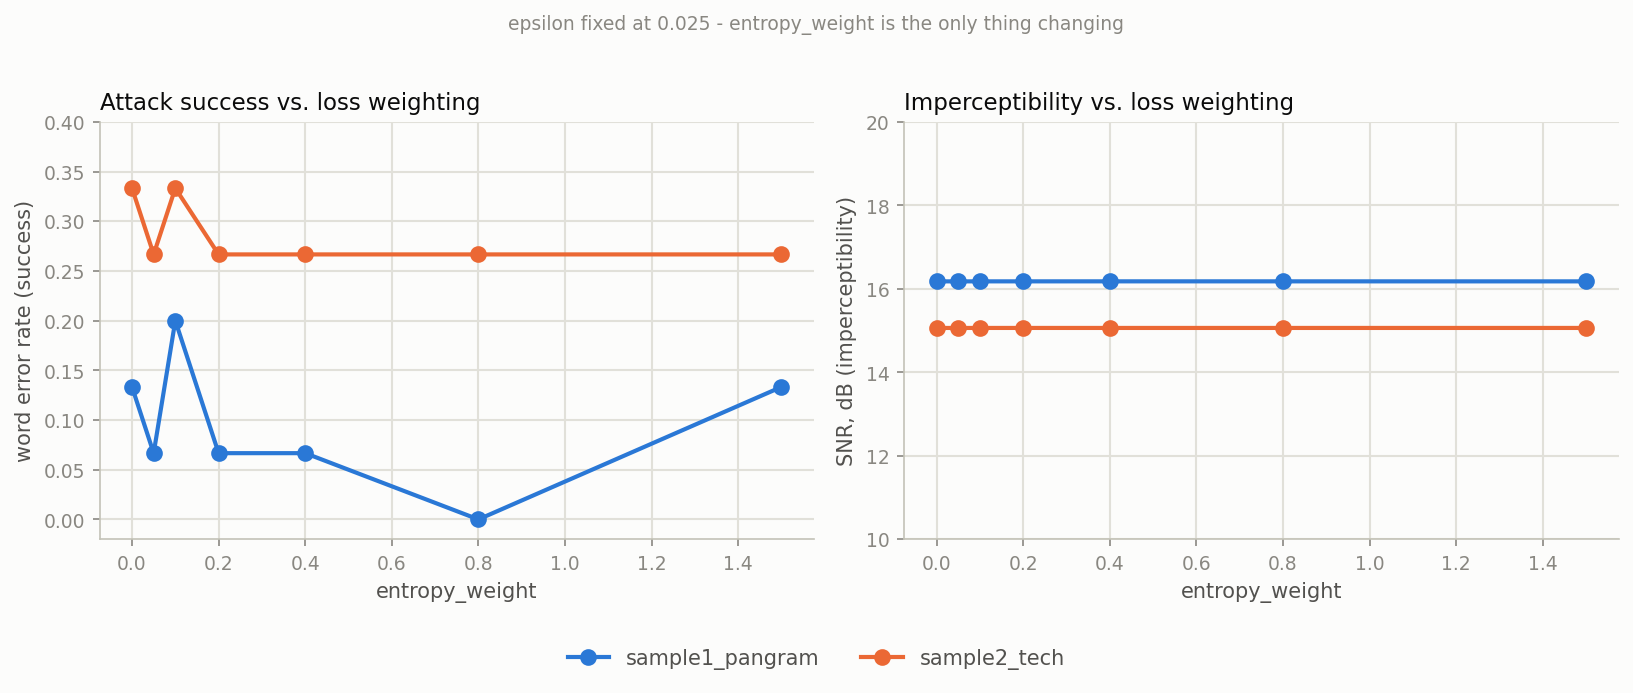

In [ ]:
import matplotlib.pyplot as plt

SURFACE, PRIMARY_INK, SECONDARY_INK = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, AXIS = "#898781", "#e1e0d9", "#c3c2b7"
COLORS = {"sample1_pangram": "#2a78d6", "sample2_tech": "#eb6834"}

by_sample = {s: sorted([r for r in sweep_results if r["sample"] == s], key=lambda r: r["entropy_weight"])
             for s in SAMPLE_STEMS}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2), facecolor=SURFACE)
for ax in (ax0, ax1):
    ax.set_facecolor(SURFACE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("entropy_weight", color=SECONDARY_INK, fontsize=10)

for s in SAMPLE_STEMS:
    xs = [r["entropy_weight"] for r in by_sample[s]]
    ax0.plot(xs, [r["word_error_rate"] for r in by_sample[s]], color=COLORS[s],
              linewidth=2, marker="o", markersize=7, label=s, zorder=3)
    ax1.plot(xs, [r["snr_db"] for r in by_sample[s]], color=COLORS[s],
              linewidth=2, marker="o", markersize=7, label=s, zorder=3)

ax0.set_ylabel("word error rate (success)", color=SECONDARY_INK, fontsize=10)
ax0.set_title("Attack success vs. loss weighting", color=PRIMARY_INK, fontsize=11, loc="left")
ax1.set_ylabel("SNR, dB (imperceptibility)", color=SECONDARY_INK, fontsize=10)
ax1.set_title("Imperceptibility vs. loss weighting", color=PRIMARY_INK, fontsize=11, loc="left")

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           labelcolor=SECONDARY_INK, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("epsilon fixed at 0.025 - entropy_weight is the only thing changing",
             color=MUTED, fontsize=9, y=1.02)
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(f"{SAMPLES_DIR}/entropy_weight_sweep.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## 6. What the sweep actually shows

**Imperceptibility (right panel) is flat**, exactly as the epsilon re-projection should make it: with `epsilon` fixed, SNR barely moves regardless of how the loss is weighted. That part of the "trick" is simple and mechanical - the perturbation budget alone controls how audible the attack can possibly be, independent of what the loss is trying to optimize for.

**Attack success (left panel) is not a dial.** There's no clean "higher entropy_weight = more success" curve here - `sample1_pangram` peaks at `entropy_weight=0.1` (WER 0.200), *drops to zero* at `0.8`, then partially recovers at `1.5`; `sample2_tech` is essentially flat with its own peak at the extremes (`0.0` and `0.1`). Plain CTC loss alone (`entropy_weight=0.0`) is competitive with every weighted variant tested, and the best setting is different per sample.

That's the real content of "the trick is the loss, and how much you touch it up": sign-based PGD (`torch.sign(grad)`) turns a smooth-looking weighted loss into a step function, so a small change in `entropy_weight` can flip which pixels/samples get perturbed at each iteration rather than smoothly scaling the result. Getting a specific attack to succeed isn't a matter of finding the "correct" entropy weight in the abstract - it has to be searched per input, and a setting that helps one clip can do nothing (or worse) for another. The epsilon budget is the part of this attack that behaves predictably; the loss weighting is the part that has to be tuned by hand, per case, exactly as reported.

## 7. Where does the perturbation actually live?

The other assumption worth checking directly rather than asserting: does psychoacoustic masking + energy filtering visibly reshape *where* (in frequency) the perturbation sits, compared to the raw PGD step before those two are applied? Captured here on `sample1_pangram`, strong config (`epsilon=0.04`), on the final PGD iteration.

In [ ]:
def run_pgd_attack_capture(processor, model, waveform, epsilon, alpha, num_iter, entropy_weight=0.2):
    """Same attack as run_pgd_attack, but also returns the pre-masking perturbation for comparison."""
    audio_tensor = waveform.clone().detach()
    text_original, logits = transcribe(processor, model, audio_tensor)
    target = processor.tokenizer(text_original, return_tensors="pt").input_ids.squeeze(0)
    input_lengths = torch.tensor([logits.shape[1]], dtype=torch.long)
    target_lengths = torch.tensor([min(target.shape[0], logits.shape[1])], dtype=torch.long)
    ctc_loss = torch.nn.CTCLoss(blank=processor.tokenizer.pad_token_id)

    adv_audio = audio_tensor.clone().detach().requires_grad_(True)
    raw_perturbation = None

    for i in range(num_iter):
        adv_audio = adv_audio.clone().detach().requires_grad_(True)
        logits = model(adv_audio.unsqueeze(0)).logits
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        entropy_loss = -torch.sum(log_probs * torch.exp(log_probs))
        alignment_loss = ctc_loss(log_probs.transpose(0, 1), target, input_lengths, target_lengths)
        loss = alignment_loss + entropy_weight * entropy_loss
        loss.backward()

        with torch.no_grad():
            grad_abs_max = torch.max(torch.abs(adv_audio.grad))
            adaptive_alpha = alpha * torch.abs(adv_audio.grad) / (grad_abs_max + 1e-12)
            perturbation = adaptive_alpha * torch.sign(adv_audio.grad)
            pre_mask_audio = adv_audio + perturbation
            if i == num_iter - 1:
                raw_perturbation = (pre_mask_audio - audio_tensor).clone()

            adv_audio = apply_psychoacoustic_masking(pre_mask_audio)
            adv_audio = apply_energy_filter(adv_audio, energy_factor=0.8)

            adv_audio = project_to_epsilon_ball(adv_audio, audio_tensor, epsilon)

    return audio_tensor, raw_perturbation, adv_audio.detach() - audio_tensor


raw_path = f"{SAMPLES_DIR}/sample1_pangram_raw.wav"
converted_path = convert_audio(raw_path)
spec_waveform, sr = torchaudio.load(converted_path)
spec_waveform = spec_waveform.mean(dim=0)
spec_waveform = spec_waveform / spec_waveform.abs().max()

clean, raw_pert, final_pert = run_pgd_attack_capture(
    processor, model, spec_waveform, epsilon=0.04, alpha=0.04 / 3, num_iter=10
)
os.remove(converted_path)

raw_np, final_np = raw_pert.numpy(), final_pert.numpy()
print(f"raw perturbation:   Linf={float(np.max(np.abs(raw_np))):.4f}  L2={float(np.linalg.norm(raw_np)):.3f}")
print(f"final perturbation: Linf={float(np.max(np.abs(final_np))):.4f}  L2={float(np.linalg.norm(final_np)):.3f}")
print(f"final vs raw correlation: {float(np.corrcoef(raw_np, final_np)[0, 1]):.4f}")
print(f"masking+filtering delta: Linf={float(np.max(np.abs(final_np - raw_np))):.4f}")

raw perturbation:   Linf=0.0486  L2=7.276
final perturbation: Linf=0.0400  L2=7.292
final vs raw correlation: 0.9997
masking+filtering delta: Linf=0.0086


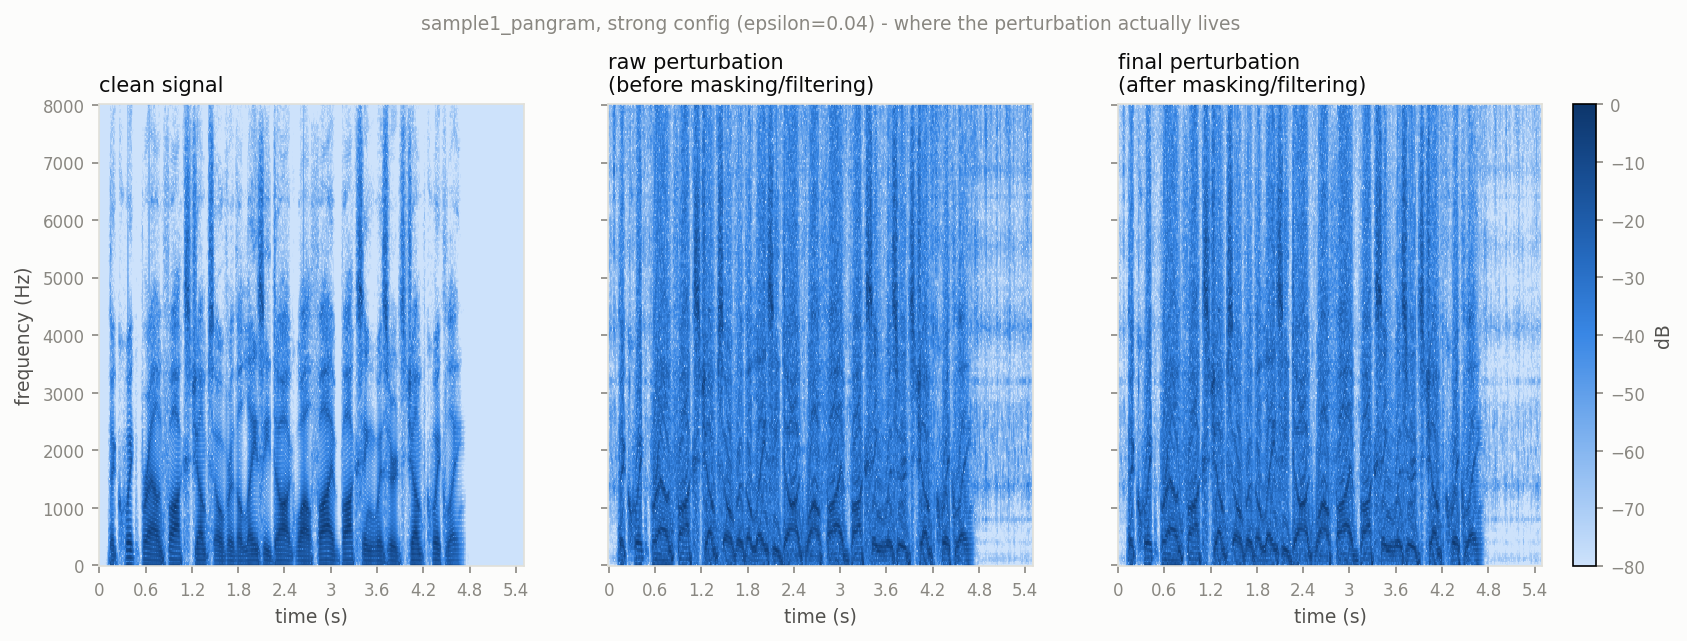

In [ ]:
import librosa.display
import matplotlib.colors as mcolors

BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
BLUE_CMAP = mcolors.LinearSegmentedColormap.from_list("blue_ramp", BLUE_RAMP)


def db_spec(x):
    S = librosa.stft(x, n_fft=512, hop_length=128)
    return librosa.amplitude_to_db(np.abs(S), ref=np.max)


specs = {
    "clean signal": db_spec(clean.numpy()),
    "raw perturbation\n(before masking/filtering)": db_spec(raw_np),
    "final perturbation\n(after masking/filtering)": db_spec(final_np),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor="#fcfcfb", sharey=True)
for ax, (title, S) in zip(axes, specs.items()):
    img = librosa.display.specshow(S, sr=16000, hop_length=128, x_axis="time", y_axis="hz",
                                    ax=ax, cmap=BLUE_CMAP, vmin=-80, vmax=0)
    ax.set_title(title, color="#0b0b0b", fontsize=10, loc="left")
    ax.set_xlabel("time (s)", color="#52514e", fontsize=9)
    ax.tick_params(colors="#898781", labelsize=8)
axes[0].set_ylabel("frequency (Hz)", color="#52514e", fontsize=9)

cbar = fig.colorbar(img, ax=axes, location="right", fraction=0.025, pad=0.02)
cbar.set_label("dB", color="#52514e", fontsize=9)
fig.suptitle("sample1_pangram, strong config (epsilon=0.04) - where the perturbation actually lives",
             color="#898781", fontsize=9, y=1.03)
fig.savefig(f"{SAMPLES_DIR}/masking_spectrogram.png", dpi=150, facecolor="#fcfcfb", bbox_inches="tight")
plt.show()

The three panels look almost the same - and the numbers confirm it isn't a rendering issue: the raw and final perturbations are **99.97% correlated**, with masking+filtering shifting things by only `Linf=0.0086` (about a fifth of the `epsilon=0.04` budget) on top of an already epsilon-saturating raw step. In this configuration, **the L-inf epsilon clamp is doing almost all of the imperceptibility work** - psychoacoustic masking and energy filtering are a real but second-order refinement on top of it, not the dominant mechanism the method names imply. That's consistent with the entropy-weight finding above: the parts of this attack that behave predictably (the epsilon budget) and the parts that need real, careful tuning to see much effect (the loss shaping, the post-processing) are different parts, and it's easy to overstate the second kind from the method names alone.